# Seaborn Case Study: E-Commerce Sales Analytics Dashboard

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [6]:

np.random.seed(42)

n = 1500

df = pd.DataFrame({
    "Order_ID": range(10001, 10001+n),
    "Order_Date": pd.date_range("2024-01-01", periods=n, freq="D"),
    "Region": np.random.choice(["North","South","East","West"], n),
    "State": np.random.choice([
        "Maharashtra","Karnataka","Delhi","Tamil Nadu",
        "Gujarat","Rajasthan","Kerala","Punjab"
    ], n),
    "Category": np.random.choice([
        "Electronics","Furniture","Clothing","Grocery","Sports"
    ], n),
    "Customer_Type": np.random.choice([
        "New","Returning","Premium"
    ], n),
    "Payment_Mode": np.random.choice([
        "UPI","Credit Card","Debit Card","Cash","Net Banking"
    ], n),
    "Shipping_Mode": np.random.choice([
        "Standard","Express","Same Day"
    ], n),
    "Sales": np.random.randint(500,80000,n),
    "Profit": np.random.randint(-8000,20000,n),
    "Discount": np.round(np.random.uniform(0,0.40,n),2),
    "Quantity": np.random.randint(1,8,n),
    "Customer_Rating": np.random.randint(1,6,n)
})

In [2]:
df.head(10)

,Order_ID,Order_Date,Region,State,Category,Customer_Type,Payment_Mode,Shipping_Mode,Sales,Profit,Discount,Quantity,Customer_Rating
0,10001,2024-01-01,East,Delhi,Furniture,Returning,Net Banking,Standard,75903,-4230,0.07,3,4
1,10002,2024-01-02,West,Rajasthan,Grocery,New,Credit Card,Express,58966,-2171,0.38,3,4
2,10003,2024-01-03,North,Rajasthan,Sports,Returning,Net Banking,Same Day,4481,-6387,0.28,2,5
3,10004,2024-01-04,East,Delhi,Sports,Returning,Net Banking,Standard,9993,5147,0.32,2,2
4,10005,2024-01-05,East,Kerala,Furniture,Premium,Debit Card,Express,71718,7545,0.16,6,4
5,10006,2024-01-06,West,Delhi,Electronics,New,UPI,Standard,71818,10263,0.13,6,2
6,10007,2024-01-07,North,Punjab,Grocery,Premium,UPI,Standard,17484,-2628,0.09,2,4
7,10008,2024-01-08,North,Karnataka,Sports,Premium,Debit Card,Express,23260,12492,0.19,5,3
8,10009,2024-01-09,East,Punjab,Furniture,Returning,Debit Card,Express,2024,2538,0.22,5,3
9,10010,2024-01-10,South,Tamil Nadu,Sports,New,Debit Card,Standard,49902,17675,0.25,1,3


In [8]:
df.tail()

,Order_ID,Order_Date,Region,State,Category,Customer_Type,Payment_Mode,Shipping_Mode,Sales,Profit,Discount,Quantity,Customer_Rating
1495,11496,2028-02-04,North,Maharashtra,Sports,New,Net Banking,Express,4518,12043,0.06,5,1
1496,11497,2028-02-05,West,Delhi,Furniture,New,Credit Card,Express,5692,7226,0.01,5,3
1497,11498,2028-02-06,West,Gujarat,Sports,Returning,Credit Card,Express,2515,-6475,0.19,1,2
1498,11499,2028-02-07,East,Karnataka,Sports,New,Debit Card,Express,69416,-7240,0.38,4,2
1499,11500,2028-02-08,East,Punjab,Furniture,New,Net Banking,Same Day,28843,8978,0.05,4,4


In [3]:
df.shape

(1500, 13)

In [9]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'State', 'Category',
       'Customer_Type', 'Payment_Mode', 'Shipping_Mode', 'Sales', 'Profit',
       'Discount', 'Quantity', 'Customer_Rating'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         1500 non-null   int64         
 1   Order_Date       1500 non-null   datetime64[ns]
 2   Region           1500 non-null   object        
 3   State            1500 non-null   object        
 4   Category         1500 non-null   object        
 5   Customer_Type    1500 non-null   object        
 6   Payment_Mode     1500 non-null   object        
 7   Shipping_Mode    1500 non-null   object        
 8   Sales            1500 non-null   int32         
 9   Profit           1500 non-null   int32         
 10  Discount         1500 non-null   float64       
 11  Quantity         1500 non-null   int32         
 12  Customer_Rating  1500 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(1), object(6)
memory usage: 129.0+ KB


In [11]:
df.describe()

,Order_ID,Order_Date,Sales,Profit,Discount,Quantity,Customer_Rating
count,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,10750.500000,2026-01-19 12:00:00,39051.184667,5744.388667,0.196813,3.989333,3.003333
min,10001.000000,2024-01-01 00:00:00,502.000000,-7989.000000,0.000000,1.000000,1.000000
25%,10375.750000,2025-01-09 18:00:00,18287.750000,-1399.500000,0.100000,2.000000,2.000000
50%,10750.500000,2026-01-19 12:00:00,37952.500000,5828.500000,0.190000,4.000000,3.000000
75%,11125.250000,2027-01-29 06:00:00,58940.250000,12682.500000,0.290000,6.000000,4.000000
max,11500.000000,2028-02-08 00:00:00,79968.000000,19975.000000,0.400000,7.000000,5.000000
std,433.157015,NaN,23243.754946,8079.129289,0.112318,2.000639,1.402605


In [10]:
df.describe(include=object)

,Region,State,Category,Customer_Type,Payment_Mode,Shipping_Mode
count,1500,1500,1500,1500,1500,1500
unique,4,8,5,3,5,3
top,North,Maharashtra,Grocery,New,Credit Card,Express
freq,394,197,328,508,309,539


In [13]:
df.nunique()

Order_ID           1500
Order_Date         1500
Region                4
State                 8
Category              5
Customer_Type         3
Payment_Mode          5
Shipping_Mode         3
Sales              1484
Profit             1459
Discount             41
Quantity              7
Customer_Rating       5
dtype: int64

In [15]:
df.isnull().sum()

Order_ID           0
Order_Date         0
Region             0
State              0
Category           0
Customer_Type      0
Payment_Mode       0
Shipping_Mode      0
Sales              0
Profit             0
Discount           0
Quantity           0
Customer_Rating    0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

## How are sales distributed across all orders?

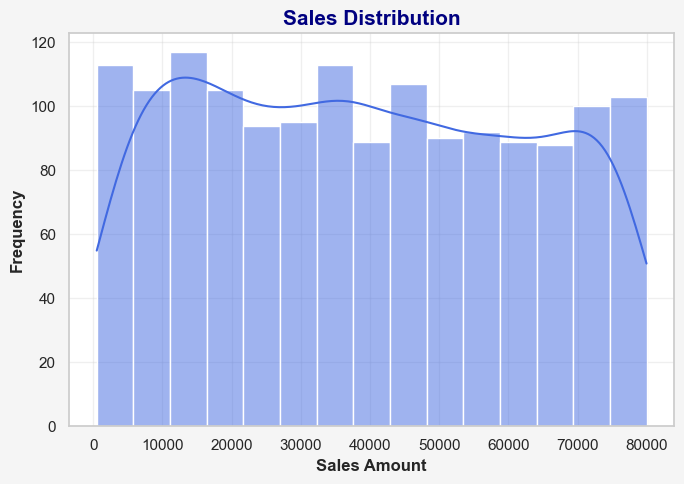

In [30]:

plt.figure(figsize=(7,5), facecolor='whitesmoke')

sns.histplot(
    data=df,
    x='Sales',
    bins=15,
    kde=True,
    color='royalblue'
)

plt.title('Sales Distribution', fontsize=15, fontweight='bold', color='navy')
plt.xlabel('Sales Amount', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Which product category has the highest number of orders?


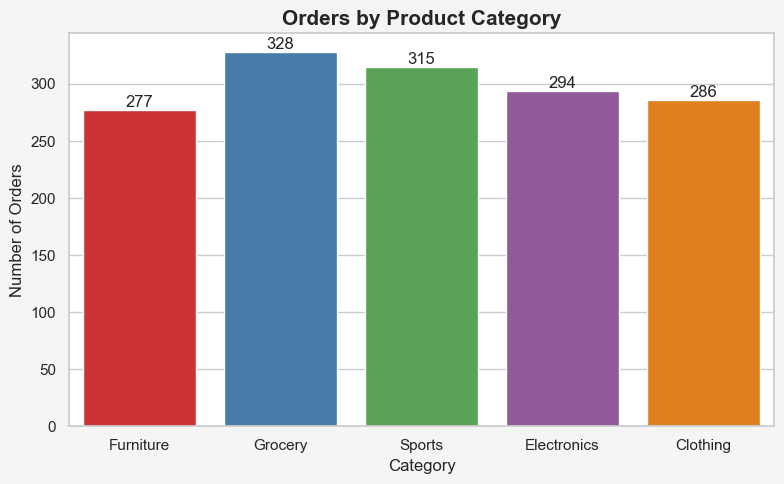

In [32]:

plt.figure(figsize=(8,5), facecolor='whitesmoke')

ax = sns.countplot(
    data=df,
    x='Category',
    hue='Category',
    palette='Set1',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Orders by Product Category', fontsize=15, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

## Are there any extreme high-value sales (outliers)?


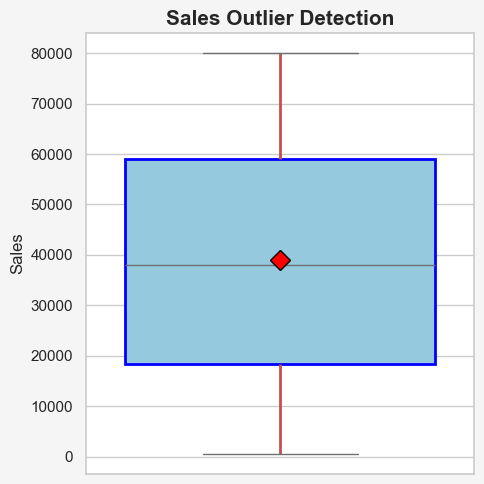

In [56]:

plt.figure(figsize=(5,5), facecolor='whitesmoke')

sns.boxplot(
    data=df,
    y='Sales',
    color='skyblue',
    showmeans=True,
    
    meanprops={
        "marker": "D",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 10
    },
    
    boxprops={
        'linewidth':2,
        'edgecolor':'blue'
        
    },
    whiskerprops={
        'linewidth':2,
        'color':'r'
    }
)

plt.title('Sales Outlier Detection', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

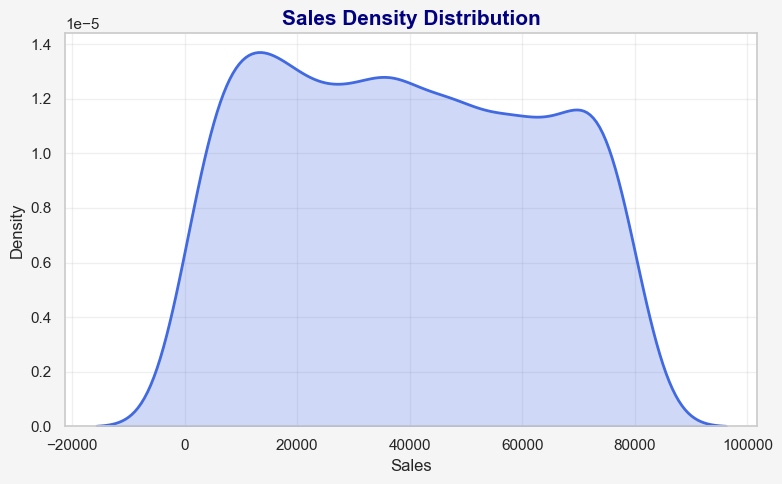

In [57]:
plt.figure(figsize=(8,5), facecolor="whitesmoke")

sns.kdeplot(
    data=df,
    x="Sales",
    fill=True,
    color="royalblue",
    linewidth=2
)

plt.title("Sales Density Distribution",fontsize=15,fontweight="bold",color="navy")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Where does every individual sale occur?

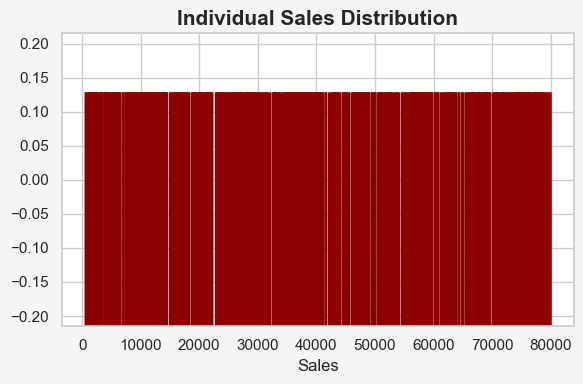

In [61]:

plt.figure(figsize=(6,4),facecolor="whitesmoke")

sns.rugplot(
    data=df,
    x="Sales",
    color="darkred",
    height=0.8
)

plt.title("Individual Sales Distribution",fontsize=15,fontweight="bold")
plt.xlabel("Sales")

plt.tight_layout()
plt.show()

## Does increasing Sales increase Profit?

### Insight
    Positive regression line → Higher sales generally generate higher profit.

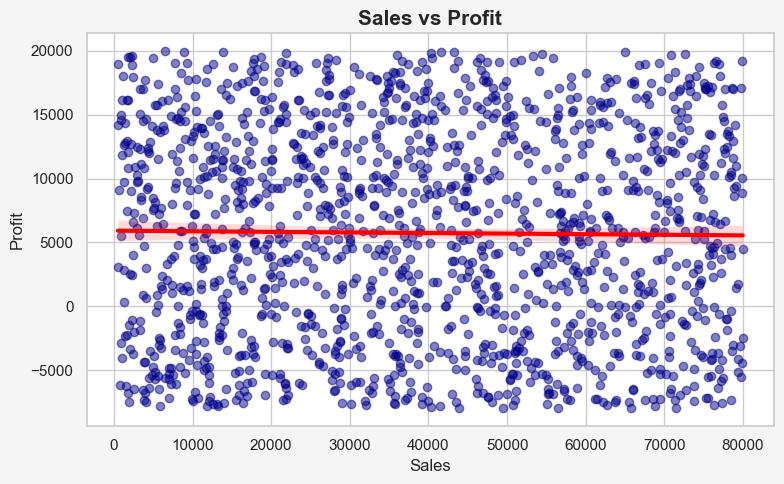

In [64]:
plt.figure(figsize=(8,5),facecolor="whitesmoke")

sns.regplot(
    data=df,
    x="Sales",
    y="Profit",
    scatter_kws={
        "alpha":0.5,
        "color":"darkblue"
    },
    line_kws={
        "color":"red",
        "linewidth":3
    }
)

plt.title("Sales vs Profit",fontsize=15,fontweight="bold")

plt.tight_layout()

plt.show()

## Does the Sales–Profit relationship differ by Customer Type?


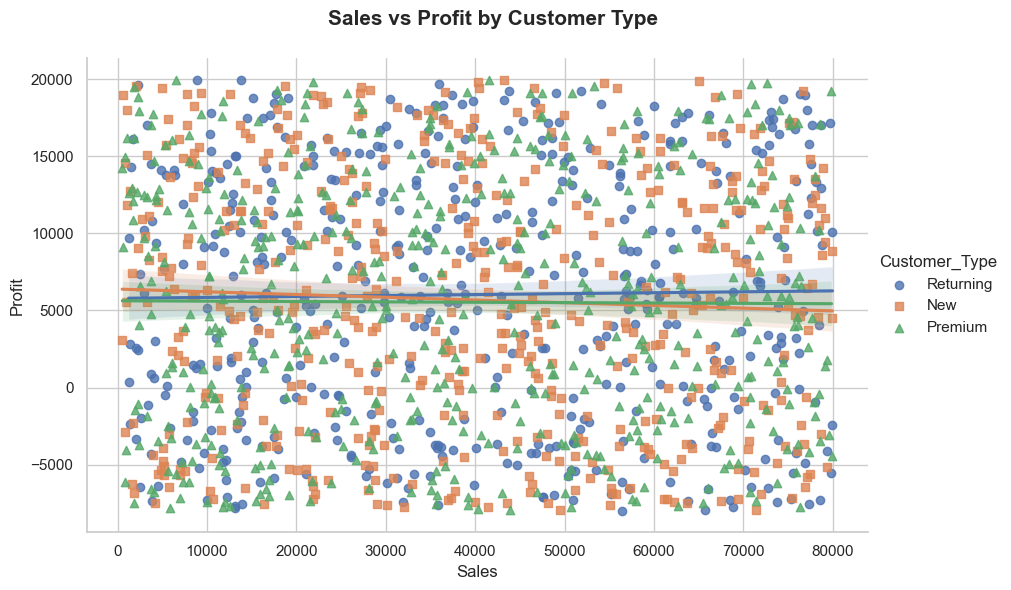

In [65]:

sns.lmplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Customer_Type",
    height=6,
    aspect=1.5,
    markers=["o","s","^"]
)

plt.suptitle("Sales vs Profit by Customer Type",
             fontsize=15,
             fontweight="bold")

plt.subplots_adjust(top=0.90)

plt.show()

## How well does Sales explain Profit?

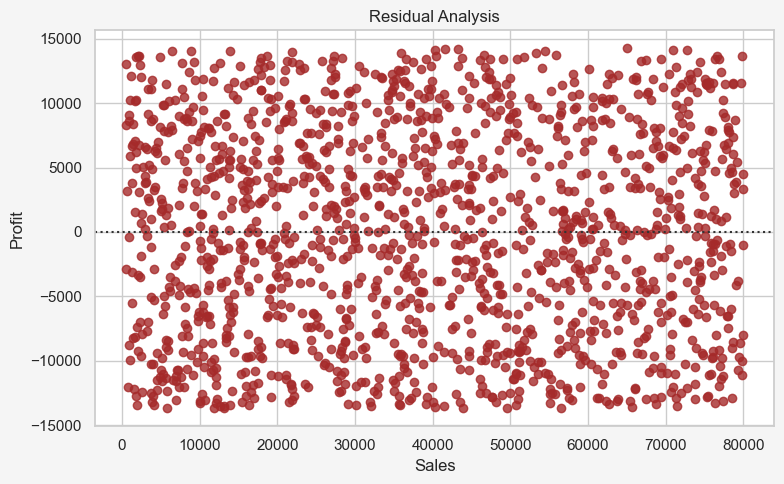

In [75]:


plt.figure(figsize=(8,5),facecolor="whitesmoke")

sns.residplot(
    data=df,
    x="Sales",
    y="Profit",
    color="brown"
)


plt.title("Residual Analysis")

plt.tight_layout()

plt.show()

### Which Region has the highest average Sales for each Customer Type?


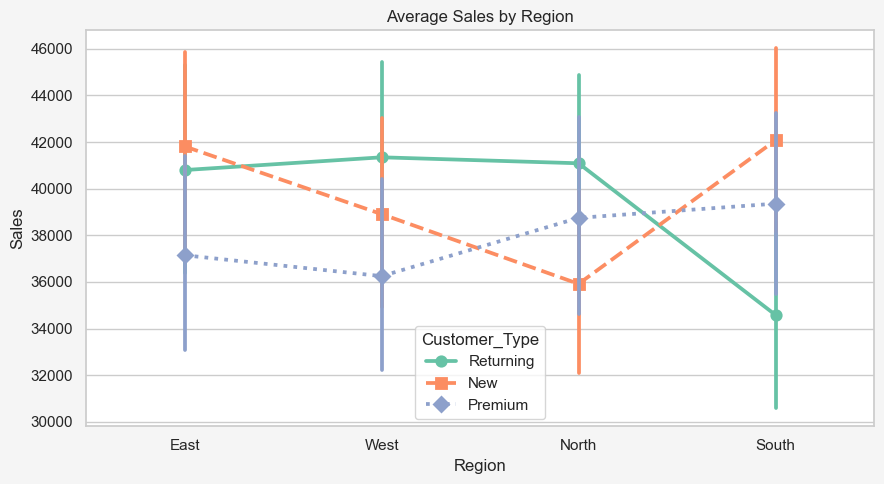

In [76]:

plt.figure(figsize=(9,5),facecolor="whitesmoke")

sns.pointplot(
    data=df,
    x="Region",
    y="Sales",
    hue="Customer_Type",
    palette="Set2",
    markers=["o","s","D"],
    linestyles=["-","--",":"]
)

plt.title("Average Sales by Region")

plt.tight_layout()

plt.show()

## Which Product Category has the widest sales distribution?


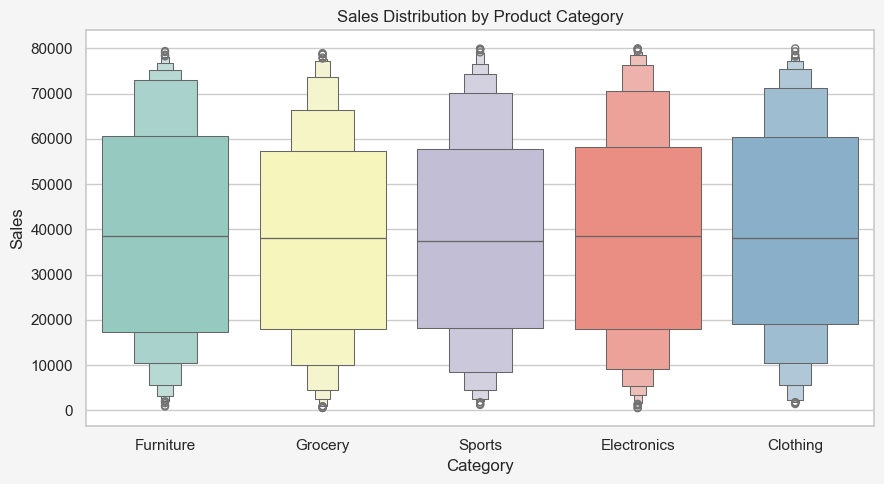

In [77]:

plt.figure(figsize=(9,5),facecolor="whitesmoke")

sns.boxenplot(
    data=df,
    x="Category",
    y="Sales",
    hue="Category",
    palette="Set3",
    legend=False
)

plt.title("Sales Distribution by Product Category")

plt.tight_layout()

plt.show()

## Relationship between Sales and Profit

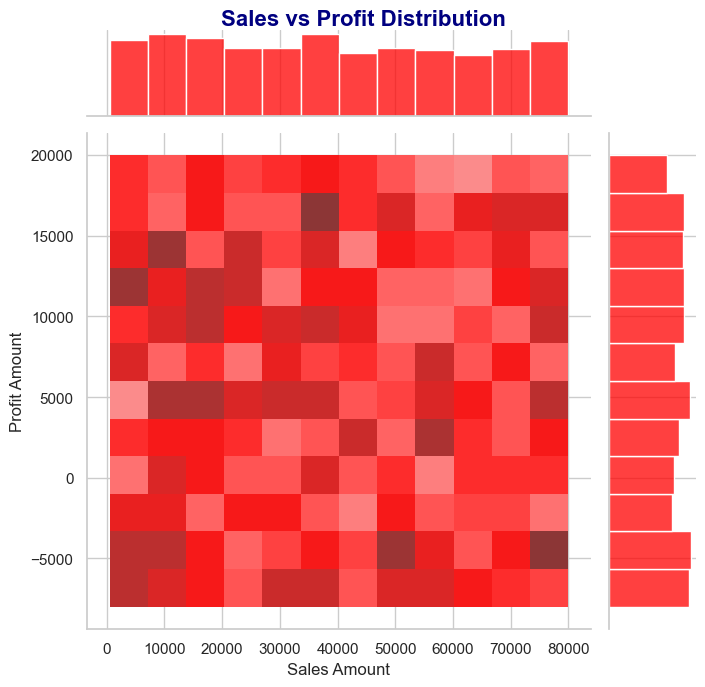

In [90]:

g=sns.jointplot(
    data=df,
    x="Sales",
    y="Profit",
    kind="hist",
    color="red",
    height=7
)

g.set_axis_labels("Sales Amount", "Profit Amount")

g.figure.suptitle(
    "Sales vs Profit Distribution",
    fontsize=16,
    fontweight="bold",
    color="navy"
)

g.figure.subplots_adjust(top=0.95)

plt.show()

plt.show()

## Which numerical variables behave similarly?


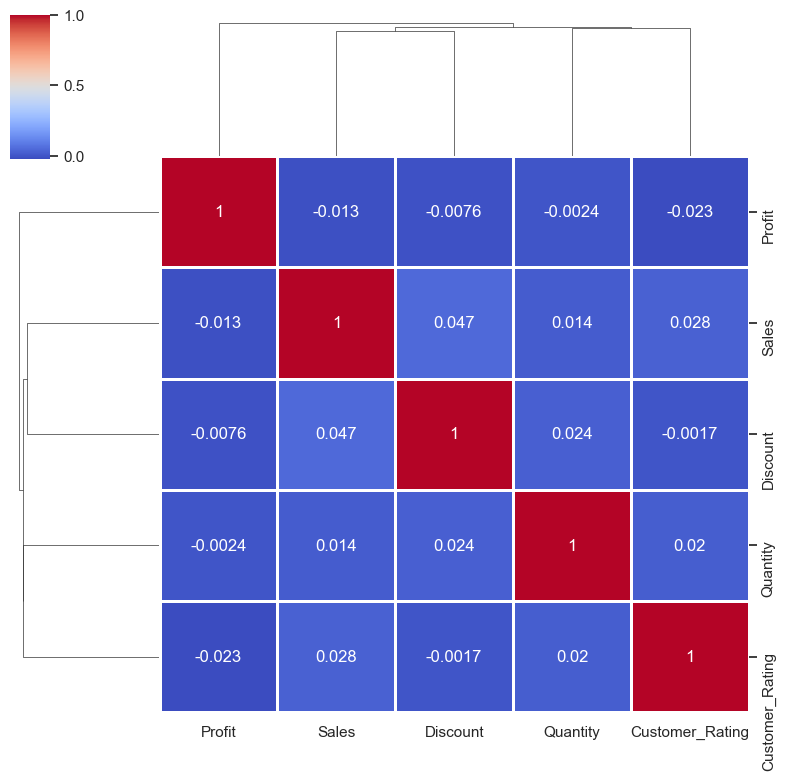

In [85]:

corr=df[
    ["Sales",
     "Profit",
     "Discount",
     "Quantity",
     "Customer_Rating"]
].corr()

sns.clustermap(
    corr,
    annot=True,
    cmap="coolwarm",
    figsize=(8,8),
    linewidths=1
)

## What percentage of orders comes from each region?


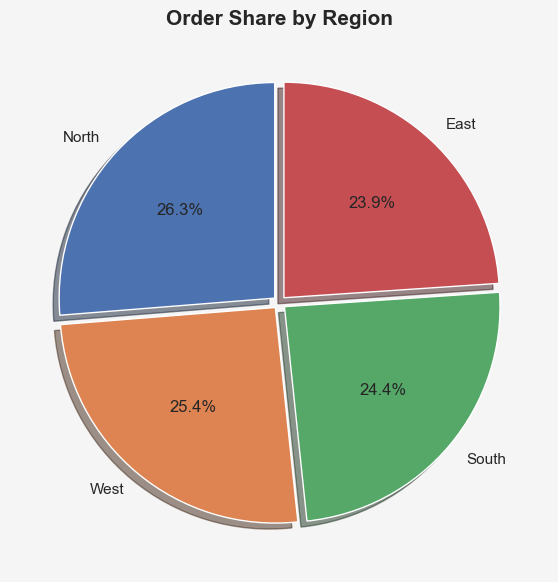

In [86]:

region=df["Region"].value_counts()

plt.figure(figsize=(7,7),facecolor="whitesmoke")

plt.pie(
    region,
    labels=region.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(region),
    shadow=True
)

plt.title(
    "Order Share by Region",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## What relationships exist among Sales, Profit, Discount, Quantity, and Customer Rating?


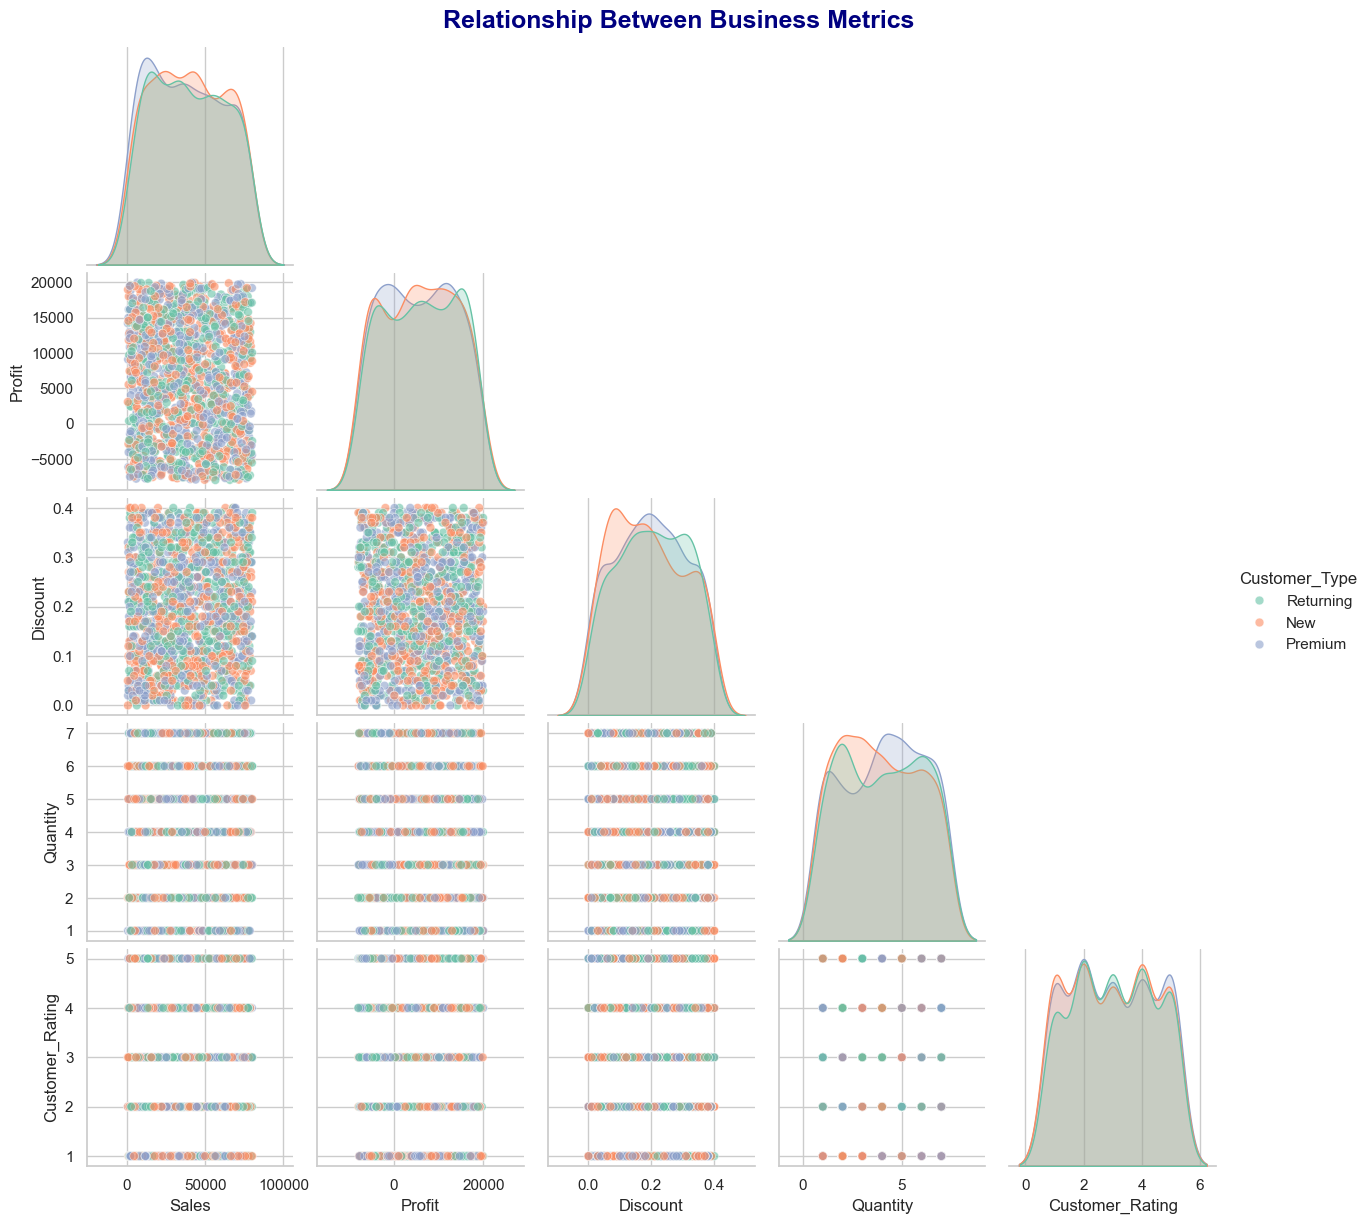

In [87]:

sns.pairplot(
    data=df,
    vars=["Sales","Profit","Discount","Quantity","Customer_Rating"],
    hue="Customer_Type",
    diag_kind="kde",
    palette="Set2",
    corner=True,
    plot_kws={
        "alpha":0.6,
        "s":40
    }
)

plt.suptitle(
    "Relationship Between Business Metrics",
    fontsize=18,
    fontweight="bold",
    color="navy"
)

plt.subplots_adjust(top=0.95)

plt.show()

## Which numerical business metrics are strongly correlated?


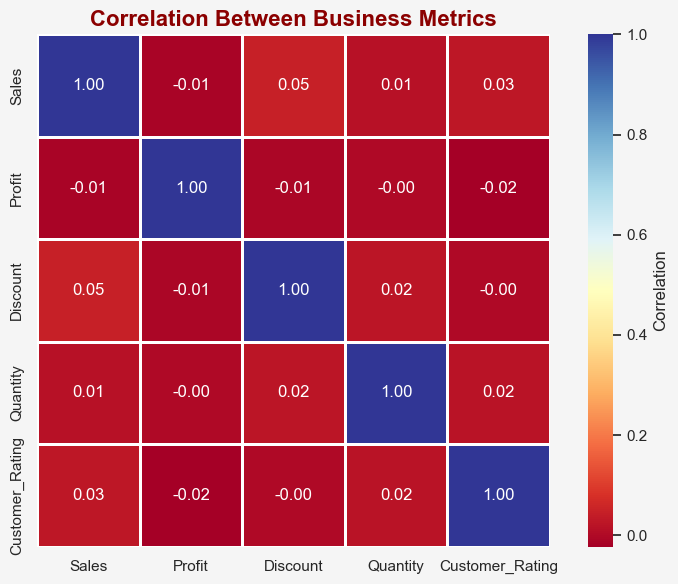

In [88]:

plt.figure(figsize=(8,6), facecolor="whitesmoke")

corr = df[
    ["Sales",
     "Profit",
     "Discount",
     "Quantity",
     "Customer_Rating"]
].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    fmt=".2f",
    linewidths=1,
    square=True,
    cbar_kws={"label":"Correlation"}
)

plt.title(
    "Correlation Between Business Metrics",
    fontsize=16,
    fontweight="bold",
    color="darkred"
)

plt.tight_layout()

plt.show()

## How is Sales distributed across different Customer Types?


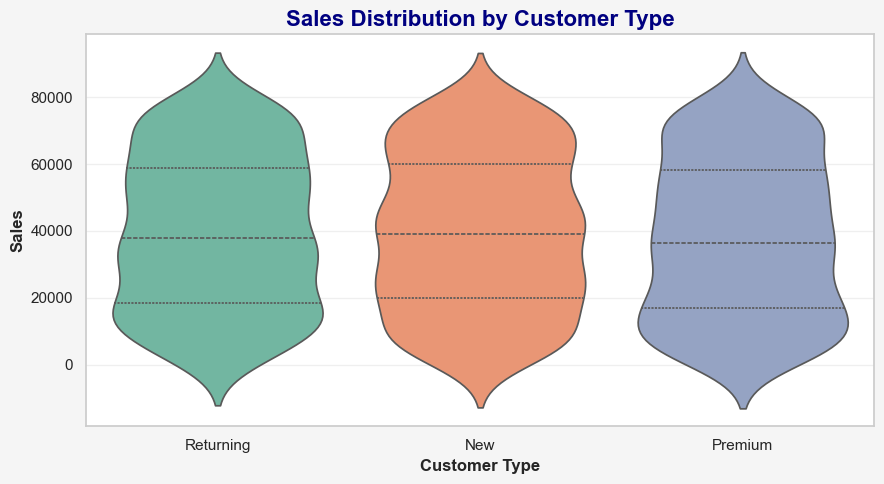

In [89]:

plt.figure(figsize=(9,5), facecolor="whitesmoke")

sns.violinplot(
    data=df,
    x="Customer_Type",
    y="Sales",
    hue="Customer_Type",
    palette="Set2",
    inner="quart",
    density_norm="width",
    legend=False
)

plt.title(
    "Sales Distribution by Customer Type",
    fontsize=16,
    fontweight="bold",
    color="navy"
)

plt.xlabel("Customer Type", fontweight="bold")
plt.ylabel("Sales", fontweight="bold")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()